# Phase 2.2: Indoor PM2.5 Forecasting (Production Evaluation)

This notebook evaluates the forecasting models developed in Phase 2.1 against the unseen 20% testing dataset. It conducts a final ablation study to quantify the value of the outdoor data source (comparing Raw LCS, Calibrated LCS, and TH2 reference data).

## Objectives
1. **Model Deployment:** Construct XGBoost and LSTM models using the hardcoded hyperparameter configurations discovered during the Phase 2.1 Grid Search.
2. **Holdout Evaluation:** Evaluate model performance strictly on the chronologically isolated 20% testing partitions to conduct independent performance evaluation.
3. **Reference Ablation Study:** Compare the predictive error of employing uncalibrated (Raw) LCS data, corrected (Calibrated) LCS data, and distant reference (TH2) data as the outdoor baseline.

## 1. Imports & Configuration

Core libraries are loaded and the specific, selected hyperparameters identified in the Phase 3.1 exploration phase are hardcoded into the pipeline.

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

pair_configs = {
    'Pair_A': {'in_pm': 'node_2_pm25', 'out_final': 'node_1_final', 'out_raw': 'node_1_pm25', 'out_dry': 'node_1_dry', 'out_humi': 'node_1_humi', 'out_t': 'node_1_temp', 'in_humi': 'node_2_humi', 'in_t': 'node_2_temp'},
    'Pair_B': {'in_pm': 'node_4_pm25', 'out_final': 'node_3_final', 'out_raw': 'node_3_pm25', 'out_dry': 'node_3_dry', 'out_humi': 'node_3_humi', 'out_t': 'node_3_temp', 'in_humi': 'node_4_humi', 'in_t': 'node_4_temp'},
    'Pair_C_Pre': {'in_pm': 'node_7_pm25', 'out_final': 'node_6_final', 'out_raw': 'node_6_pm25', 'out_dry': 'node_6_dry', 'out_humi': 'node_6_humi', 'out_t': 'node_6_temp', 'in_humi': 'node_7_humi', 'in_t': 'node_7_temp'},
    'Pair_C_Post': {'in_pm': 'node_7_pm25', 'out_final': 'node_6_final', 'out_raw': 'node_6_pm25', 'out_dry': 'node_6_dry', 'out_humi': 'node_6_humi', 'out_t': 'node_6_temp', 'in_humi': 'node_7_humi', 'in_t': 'node_7_temp'}
}

# Hardcoded optimal parameters discovered during Phase 2.1
import json
try:
    with open('../data/05_forecasting/parameters/optimal_parameters.json', 'r') as f:
        optimal_configs = json.load(f)
except FileNotFoundError:
    print('Warning: optimal_parameters.json not found.')
    optimal_configs = {}

## 2. Data Ingestion & Splitting

The raw 1-minute data is ingested, re-sampled to 1-hour intervals, and joined with the TH2 reference monitor data. The exact chronological splits (70/10/20) established in Phase 3.1 are recreated to evaluate the test subset.

In [ ]:
df_raw = pd.read_csv('../data/04_calibrated_master/calibrated_master_1min.csv', parse_dates=['timestamp_utc'], index_col='timestamp_utc')
df_ref = pd.read_csv('../data/02_interim/master_combined_15min.csv', parse_dates=['timestamp_utc'], index_col='timestamp_utc')
df_th2 = df_ref[['th2_mer_pm25']].resample('1h').mean()

# --- WIND DATA INJECTION (EGLC) ---
df_weather = pd.read_csv('../data/01_raw/exo_filter/EGLC.csv', parse_dates=['valid'], index_col='valid')
df_weather = df_weather[['sped', 'drct']].copy()
df_weather['wind_speed_ms'] = df_weather['sped'] * 0.44704
df_weather['wind_sin'] = np.sin(np.radians(df_weather['drct']))
df_weather['wind_cos'] = np.cos(np.radians(df_weather['drct']))
df_weather.drop(columns=['sped', 'drct'], inplace=True)
df_weather.index = df_weather.index.tz_localize('UTC')
weather_hourly = df_weather.resample('1h').mean()
# ---------------------------

hourly_datasets = {}
for name, config in pair_configs.items():
    cols = list(set([c for c in config.values() if c in df_raw.columns]))
    
    if name == 'Pair_C_Pre':
        df_sub = df_raw[df_raw.index <= '2025-06-16 12:30:00'][cols].copy()
    elif name == 'Pair_C_Post':
        df_sub = df_raw[df_raw.index >= '2025-06-19 14:00:00'][cols].copy()
    else:
        df_sub = df_raw[cols].copy()
        
    df_hourly = df_sub.resample('1h').mean()
    df_hourly = df_hourly.join(df_th2, how='left')
    df_hourly = df_hourly.join(weather_hourly, how='left')  # INJECTED EGLC DATA HERE
    
    df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly.index.hour / 24.0)
    df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly.index.hour / 24.0)
    df_hourly['day_sin'] = np.sin(2 * np.pi * df_hourly.index.dayofweek / 7.0)
    df_hourly['day_cos'] = np.cos(2 * np.pi * df_hourly.index.dayofweek / 7.0)
    
    n = len(df_hourly)
    train_idx, val_idx = int(n * 0.7), int(n * 0.8)
    
    hourly_datasets[name] = {
        'train': df_hourly.iloc[:train_idx],
        'val': df_hourly.iloc[train_idx:val_idx],
        'test': df_hourly.iloc[val_idx:]
    }

print("Data ingested, re-sampled, EGLC merged, TH2 merged, and split into Train/Val/Test.")


Data ingested, re-sampled, EGLC merged, TH2 merged, and split into Train/Val/Test.


## 3. Core Functions

Methods for tensor sequence generation and reverse scaling are established to prevent data leakage during final evaluation.

In [ ]:
def create_sequences(df, feature_cols, target_col, lookback=1, horizons=3):
    # Constructs multi-horizon temporal sequences, dropping intervals containing null values 
    X, y = [], []
    data = df[feature_cols].values
    target = df[target_col].values
    
    for i in range(len(df) - lookback - horizons + 1):
        x_seq = data[i:(i + lookback)]
        y_seq = target[(i + lookback):(i + lookback + horizons)]
        
        if np.isnan(x_seq).any() or np.isnan(y_seq).any():
            continue
            
        X.append(x_seq)
        y.append(y_seq)
        
    return np.array(X), np.array(y)

def unscale_matrix(matrix, scaler):
    # Reverses the MinMax scaling transformation across multi-horizon prediction matrices 
    # To restore values to their original physical units.
    res = np.zeros_like(matrix)
    for i in range(matrix.shape[1]):
        res[:, i] = scaler.inverse_transform(matrix[:, i].reshape(-1, 1)).flatten()
    return res

## 4. Production Evaluation & Outdoor Source Ablation

Models are trained on the training partition and evaluated strictly against the 20% holdout test partition. This step sequentially replaces the outdoor feature with the raw LCS, calibrated LCS, and TH2 reference monitor data to assess predictive dependency on the outdoor proxy.

In [ ]:
results_list = []

print("Executing Final Production Evaluation on Holdout Test Set\n" + "="*85)

# Iterates through location datasets to extract optimal configurations and isolate the holdout test set.
for pair, data in hourly_datasets.items():
    conf = optimal_configs.get(pair, {})
    
    lookback_xgb = conf.get('xgb_lookback', 1)
    lookback_lstm = conf.get('lstm_lookback', 1)
    feat_set_xgb = conf.get('xgb_features', 'Full')
    feat_set_lstm = conf.get('lstm_features', 'Full')
    
    target = pair_configs[pair]['in_pm']
    
    train_raw = data['train'].copy()
    val_raw = data['val'].copy()
    test_raw = data['test'].copy()
    
    met_cols = [c for c in [pair_configs[pair].get('in_humi'), pair_configs[pair].get('in_t'), 
                            pair_configs[pair].get('out_humi'), pair_configs[pair].get('out_t'), 'wind_speed_ms', 'wind_sin', 'wind_cos'] if c in train_raw.columns]
    time_cols = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos']
    
    outdoor_variations = {
        'Raw LCS': pair_configs[pair]['out_raw'],
        'Dried LCS': pair_configs[pair]['out_dry'],
        'TH2 Reference': 'th2_mer_pm25'
    }

    # Iterates over distinct outdoor data sources to evaluate their independent impact on model performance.
    for var_name, out_col in outdoor_variations.items():
        if out_col not in train_raw.columns:
            continue
            
        features_xgb = [target, out_col] + met_cols + time_cols if feat_set_xgb == 'Full' else [target, out_col] + time_cols
        features_lstm = [target, out_col] + met_cols + time_cols if feat_set_lstm == 'Full' else [target, out_col] + time_cols
        
        # --- XGBoost Evaluation ---
        # Applies scaling and sequence generation for XGBoost using the isolated holdout test set.
        scaler_xgb = MinMaxScaler()
        target_scaler_xgb = MinMaxScaler()
        
        train_scaled_xgb = train_raw.copy()
        test_scaled_xgb = test_raw.copy()
        
        train_scaled_xgb[features_xgb] = scaler_xgb.fit_transform(train_raw[features_xgb])
        test_scaled_xgb[features_xgb] = scaler_xgb.transform(test_raw[features_xgb])
        target_scaler_xgb.fit(train_raw[[target]])
        
        X_train_xgb, y_train_xgb = create_sequences(train_scaled_xgb, features_xgb, target, lookback_xgb, horizons=3)
        X_test_xgb, y_test_xgb = create_sequences(test_scaled_xgb, features_xgb, target, lookback_xgb, horizons=3)
        
        if len(X_train_xgb) > 0 and len(X_test_xgb) > 0:
            X_train_xgb_flat = X_train_xgb.reshape(X_train_xgb.shape[0], -1)
            X_test_xgb_flat = X_test_xgb.reshape(X_test_xgb.shape[0], -1)
            
            xgb_base = XGBRegressor(**conf.get('xgb', {}), random_state=42, n_jobs=-1)
            xgb_model = MultiOutputRegressor(xgb_base)
            # Fit MultiOutput tree-based model on 2D flattened temporal features
            xgb_model.fit(X_train_xgb_flat, y_train_xgb)
            xgb_preds = xgb_model.predict(X_test_xgb_flat)
            
            y_test_unscaled_xgb = unscale_matrix(y_test_xgb, target_scaler_xgb)
            xgb_preds_unscaled = unscale_matrix(xgb_preds, target_scaler_xgb)
            
            y_last_xgb = unscale_matrix(X_test_xgb[:, -1, 0].reshape(-1, 1), target_scaler_xgb).flatten()

            # Calculates error metrics, including Directional Accuracy (DA), across all three forecasting horizons.
            xgb_rmse = [np.sqrt(mean_squared_error(y_test_unscaled_xgb[:, i], xgb_preds_unscaled[:, i])) for i in range(3)]
            xgb_mae = [mean_absolute_error(y_test_unscaled_xgb[:, i], xgb_preds_unscaled[:, i]) for i in range(3)]
            xgb_mape = [mean_absolute_percentage_error(y_test_unscaled_xgb[:, i], xgb_preds_unscaled[:, i]) for i in range(3)]
            xgb_r2 = [r2_score(y_test_unscaled_xgb[:, i], xgb_preds_unscaled[:, i]) for i in range(3)]
            xgb_da = [np.mean(np.sign(y_test_unscaled_xgb[:, i] - y_last_xgb) == np.sign(xgb_preds_unscaled[:, i] - y_last_xgb)) * 100 for i in range(3)]
        else:
            xgb_rmse = xgb_mae = xgb_mape = xgb_r2 = xgb_da = [np.nan, np.nan, np.nan]
            
        # --- LSTM Evaluation ---
        scaler_lstm = MinMaxScaler()
        target_scaler_lstm = MinMaxScaler()
        
        train_scaled_lstm = train_raw.copy()
        val_scaled_lstm = val_raw.copy()
        test_scaled_lstm = test_raw.copy()
        
        train_scaled_lstm[features_lstm] = scaler_lstm.fit_transform(train_raw[features_lstm])
        val_scaled_lstm[features_lstm] = scaler_lstm.transform(val_raw[features_lstm])
        test_scaled_lstm[features_lstm] = scaler_lstm.transform(test_raw[features_lstm])
        target_scaler_lstm.fit(train_raw[[target]])
        
        X_train_lstm, y_train_lstm = create_sequences(train_scaled_lstm, features_lstm, target, lookback_lstm, horizons=3)
        X_val_lstm, y_val_lstm = create_sequences(val_scaled_lstm, features_lstm, target, lookback_lstm, horizons=3)
        X_test_lstm, y_test_lstm = create_sequences(test_scaled_lstm, features_lstm, target, lookback_lstm, horizons=3)
        
        if len(X_train_lstm) > 0 and len(X_test_lstm) > 0:
            early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

            # Constructs and trains the LSTM model using the optimal hyperparameters determined during the grid search phase.
            lstm_model = Sequential([
                Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
                LSTM(conf.get('lstm', {}).get('lstm_units', 32)),
                Dropout(conf.get('lstm', {}).get('dropout_rate', 0.1)),
                Dense(3)
            ])
            lstm_model.compile(optimizer=Adam(learning_rate=conf.get('lstm', {}).get('learning_rate', 0.01)), loss='mse')
            lstm_model.fit(X_train_lstm, y_train_lstm, epochs=200, batch_size=conf.get('lstm', {}).get('batch_size', 32), 
                           validation_data=(X_val_lstm, y_val_lstm), callbacks=[early_stop], verbose=0)
                           
            lstm_preds = lstm_model.predict(X_test_lstm, verbose=0)
            y_test_unscaled_lstm = unscale_matrix(y_test_lstm, target_scaler_lstm)
            lstm_preds_unscaled = unscale_matrix(lstm_preds, target_scaler_lstm)
            
            y_last_lstm = unscale_matrix(X_test_lstm[:, -1, 0].reshape(-1, 1), target_scaler_lstm).flatten()
            
            lstm_rmse = [np.sqrt(mean_squared_error(y_test_unscaled_lstm[:, i], lstm_preds_unscaled[:, i])) for i in range(3)]
            lstm_mae = [mean_absolute_error(y_test_unscaled_lstm[:, i], lstm_preds_unscaled[:, i]) for i in range(3)]
            lstm_mape = [mean_absolute_percentage_error(y_test_unscaled_lstm[:, i], lstm_preds_unscaled[:, i]) for i in range(3)]
            lstm_r2 = [r2_score(y_test_unscaled_lstm[:, i], lstm_preds_unscaled[:, i]) for i in range(3)]
            lstm_da = [np.mean(np.sign(y_test_unscaled_lstm[:, i] - y_last_lstm) == np.sign(lstm_preds_unscaled[:, i] - y_last_lstm)) * 100 for i in range(3)]
        else:
            lstm_rmse = lstm_mae = lstm_mape = lstm_r2 = lstm_da = [np.nan, np.nan, np.nan]
            
        for i in range(3):
            results_list.append({
                'Pair': pair, 'Source': var_name, 'Horizon': f"t+{i+1}",
                'XGB_RMSE': xgb_rmse[i], 'XGB_MAE': xgb_mae[i], 'XGB_MAPE': xgb_mape[i], 'XGB_R2': xgb_r2[i], 'XGB_DA(%)': xgb_da[i],
                'LSTM_RMSE': lstm_rmse[i], 'LSTM_MAE': lstm_mae[i], 'LSTM_MAPE': lstm_mape[i], 'LSTM_R2': lstm_r2[i], 'LSTM_DA(%)': lstm_da[i]
            })

# Aggregates evaluation metrics into a tabular format and exports the final results to a CSV file.                       
df_results = pd.DataFrame(results_list)
# Round metrics for clean display
cols_to_round = ['XGB_RMSE', 'XGB_MAE', 'XGB_MAPE', 'XGB_R2', 'XGB_DA(%)', 'LSTM_RMSE', 'LSTM_MAE', 'LSTM_MAPE', 'LSTM_R2', 'LSTM_DA(%)']
df_results[cols_to_round] = df_results[cols_to_round].round(3)

display(df_results)

os.makedirs('../data/06_outputs/phase2.2', exist_ok=True)
df_results.to_csv('../data/06_outputs/phase2.2/final_test_evaluation.csv', index=False)
print("Saved final metrics to ../data/06_outputs/phase2.2/final_test_evaluation.csv")

Executing Final Production Evaluation on Holdout Test Set


,Pair,Source,Horizon,XGB_RMSE,XGB_MAE,XGB_MAPE,XGB_R2,XGB_DA(%),LSTM_RMSE,LSTM_MAE,LSTM_MAPE,LSTM_R2,LSTM_DA(%)
0,Pair_A,Raw LCS,t+1,0.279,0.203,0.256,0.945,55.865,0.414,0.312,0.398,0.879,51.913
1,Pair_A,Raw LCS,t+2,0.415,0.286,0.340,0.878,57.555,0.457,0.317,0.365,0.852,55.340
2,Pair_A,Raw LCS,t+3,0.546,0.361,0.422,0.789,58.101,0.574,0.411,0.508,0.767,56.284
3,Pair_A,Dried LCS,t+1,0.277,0.204,0.257,0.946,55.219,0.414,0.318,0.389,0.879,51.664
4,Pair_A,Dried LCS,t+2,0.428,0.290,0.343,0.871,56.859,0.554,0.320,0.279,0.783,55.936
5,Pair_A,Dried LCS,t+3,0.577,0.371,0.430,0.765,57.406,0.691,0.383,0.316,0.662,54.844
6,Pair_A,TH2 Reference,t+1,0.298,0.222,0.278,0.940,55.119,0.377,0.311,0.368,0.902,53.066
7,Pair_A,TH2 Reference,t+2,0.452,0.323,0.388,0.861,56.034,0.460,0.320,0.323,0.854,54.968
8,Pair_A,TH2 Reference,t+3,0.597,0.410,0.488,0.757,55.550,0.560,0.361,0.331,0.783,56.342
9,Pair_B,Raw LCS,t+1,0.745,0.384,0.157,0.851,58.368,0.901,0.608,0.268,0.779,57.518


Saved final metrics to ../data/06_outputs/phase3.2/final_test_evaluation.csv


## 5. Visualization: Architectural Extrapolation Comparison

A time-series plot comparing the predictive curves of XGBoost and LSTM against the true indoor PM2.5 during a peak infiltration event, illustrating the architectural limitations of tree-based models in out-of-distribution extrapolation.

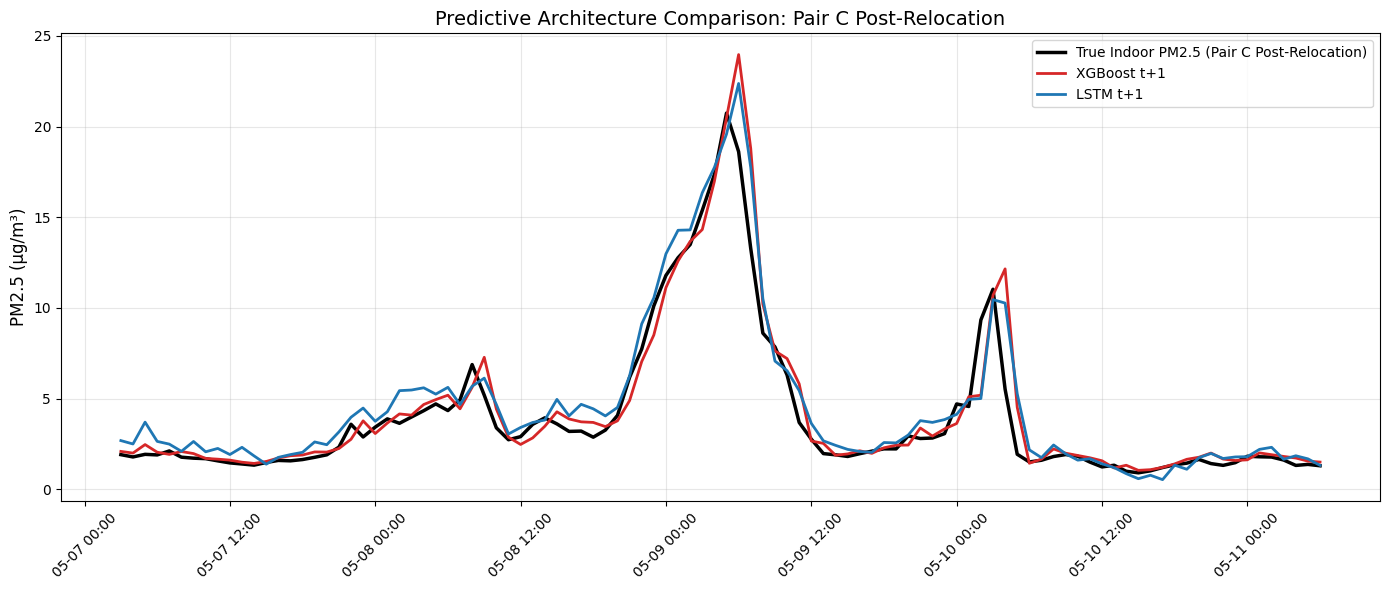

In [ ]:
pair_to_plot = 'Pair_C_Post'
conf = optimal_configs[pair_to_plot]
data = hourly_datasets[pair_to_plot]

def get_valid_timeline(df, feature_cols, target_col, lookback=1, horizons=3):
    valid_idx = []
    dataset = df[feature_cols].values
    target_data = df[target_col].values
    for i in range(len(df) - lookback - horizons + 1):
        x_seq = dataset[i:(i + lookback)]
        y_seq = target_data[(i + lookback):(i + lookback + horizons)]
        if np.isnan(x_seq).any() or np.isnan(y_seq).any():
            continue
        valid_idx.append(df.index[i + lookback])
    return valid_idx

timeline_xgb = get_valid_timeline(data['test'], features_xgb, target, conf.get('xgb_lookback', 1), horizons=3)
timeline_lstm = get_valid_timeline(data['test'], features_lstm, target, conf.get('lstm_lookback', 1), horizons=3)

df_xgb = pd.DataFrame({
    'True': y_test_unscaled_xgb[:, 0],
    'XGB_t1': xgb_preds_unscaled[:, 0]
}, index=timeline_xgb)

df_lstm = pd.DataFrame({
    'LSTM_t1': lstm_preds_unscaled[:, 0]
}, index=timeline_lstm)

plot_df = df_xgb.join(df_lstm, how='inner')

if len(plot_df) > 0:
    import matplotlib.dates as mdates
    
    peak_idx = plot_df['True'].argmax()
    window_start = max(0, peak_idx - 50)
    window_end = min(len(plot_df), peak_idx + 50)

    plot_df = plot_df.iloc[window_start:window_end]
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(plot_df.index, plot_df['True'], color='black', linewidth=2.5, label='True Indoor PM2.5 (Pair C Post-Relocation)')
    ax.plot(plot_df.index, plot_df['XGB_t1'], color='tab:red', linestyle='-', linewidth=2, label='XGBoost t+1')
    ax.plot(plot_df.index, plot_df['LSTM_t1'], color='tab:blue', linestyle='-', linewidth=2, label='LSTM t+1')

    ax.set_title('Predictive Architecture Comparison: Pair C Post-Relocation', fontsize=14)
    ax.set_ylabel('PM2.5 (µg/m³)', fontsize=12)
    # Removed X-axis label as datetime ticks are self-explanatory
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    import os
    out_dir = '../data/06_outputs/phase2.2'
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(f'{out_dir}/architectural_extrapolation_pair_c_post.png', dpi=300, bbox_inches='tight')
    plt.show()

## 6. Visualization: Forecasting Horizon Degradation
A line chart illustrating the degradation of Root Mean Squared Error (RMSE) as the forecasting horizon extends from 1 to 3 hours.

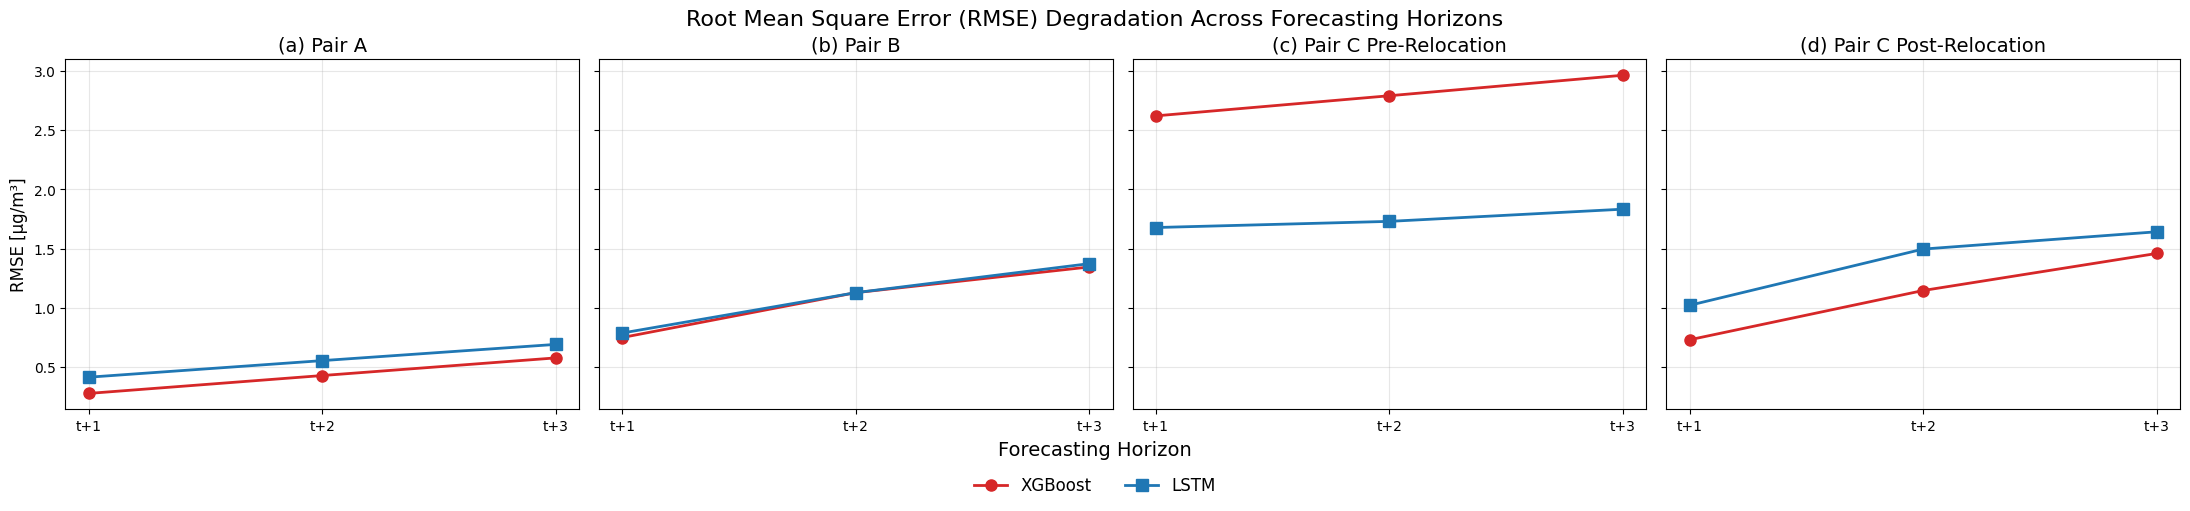

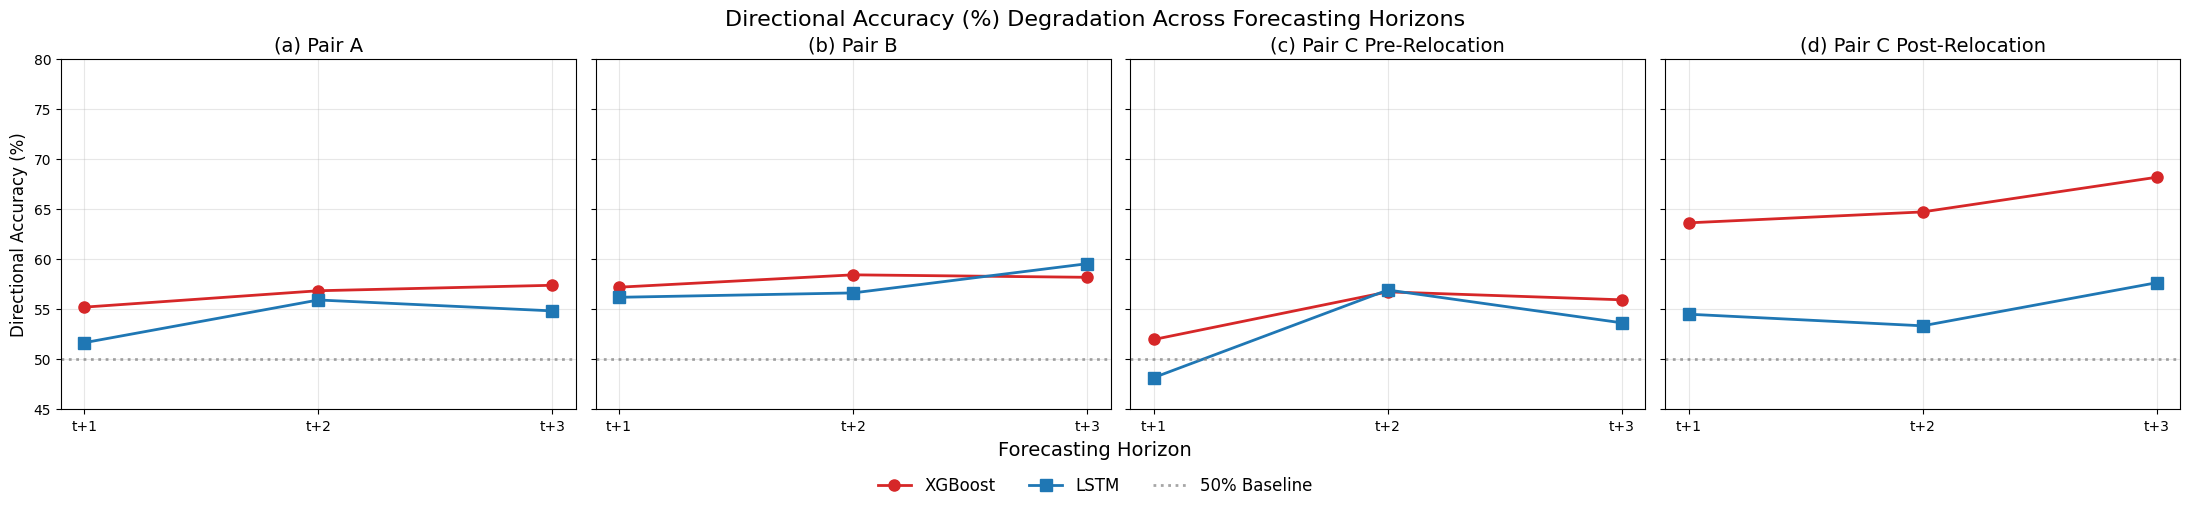

In [ ]:
pairs_to_plot = ['Pair_A', 'Pair_B', 'Pair_C_Pre', 'Pair_C_Post']
source_to_plot = 'Dried LCS'

title_map = {
    'Pair_A': '(a) Pair A',
    'Pair_B': '(b) Pair B',
    'Pair_C_Pre': '(c) Pair C Pre-Relocation',
    'Pair_C_Post': '(d) Pair C Post-Relocation'
}

import os
out_dir = '../data/06_outputs/phase2.2'
os.makedirs(out_dir, exist_ok=True)

# --- FIGURE 1: RMSE DEGRADATION ---
fig1, axes1 = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
axes1 = axes1.flatten()

for idx, pair in enumerate(pairs_to_plot):
    pair_results = df_results[(df_results['Pair'] == pair) & (df_results['Source'] == source_to_plot)]
    
    if not pair_results.empty:
        horizons = ['t+1', 't+2', 't+3']
        xgb_rmse = pair_results['XGB_RMSE'].values
        lstm_rmse = pair_results['LSTM_RMSE'].values
        
        ax = axes1[idx]
        ax.plot(horizons, xgb_rmse, marker='o', markersize=8, color='tab:red', linestyle='-', linewidth=2, label='XGBoost')
        ax.plot(horizons, lstm_rmse, marker='s', markersize=8, color='tab:blue', linestyle='-', linewidth=2, label='LSTM')
        
        ax.set_title(f'{title_map[pair]}', fontsize=14)
        if idx == 0:
            ax.set_ylabel('RMSE [μg/m³]', fontsize=12)
        
        ax.grid(True, alpha=0.3)

fig1.suptitle('Root Mean Square Error (RMSE) Degradation Across Forecasting Horizons', fontsize=16, y=1.0)
fig1.supxlabel('Forecasting Horizon', fontsize=14, y=0.10)

handles, labels = axes1[0].get_legend_handles_labels()
fig1.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False, fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.20, top=0.90)
fig1.savefig(f'{out_dir}/rmse_degradation.png', dpi=300, bbox_inches='tight')
plt.show()

# --- FIGURE 2: DIRECTIONAL ACCURACY DEGRADATION ---
fig2, axes2 = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
axes2 = axes2.flatten()

for idx, pair in enumerate(pairs_to_plot):
    pair_results = df_results[(df_results['Pair'] == pair) & (df_results['Source'] == source_to_plot)]
    
    if not pair_results.empty:
        horizons = ['t+1', 't+2', 't+3']
        xgb_da = pair_results['XGB_DA(%)'].values
        lstm_da = pair_results['LSTM_DA(%)'].values
        
        ax = axes2[idx]
        ax.plot(horizons, xgb_da, marker='o', markersize=8, color='tab:red', linestyle='-', linewidth=2, label='XGBoost')
        ax.plot(horizons, lstm_da, marker='s', markersize=8, color='tab:blue', linestyle='-', linewidth=2, label='LSTM')
        
        ax.set_title(f'{title_map[pair]}', fontsize=14)
        if idx == 0:
            ax.set_ylabel('Directional Accuracy (%)', fontsize=12)
        
        ax.set_ylim(45, 80)
        ax.axhline(y=50, color='gray', linestyle=':', alpha=0.7, linewidth=2, label='50% Baseline')
        
        ax.grid(True, alpha=0.3)

# Reduced y offset to bring main title closer to subplot titles
fig2.suptitle('Directional Accuracy (%) Degradation Across Forecasting Horizons', fontsize=16, y=1.0)
fig2.supxlabel('Forecasting Horizon', fontsize=14, y=0.10)

handles2, labels2 = axes2[0].get_legend_handles_labels()
fig2.legend(handles2, labels2, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False, fontsize=12)

plt.tight_layout()
# Pushed top up to 0.90 to reduce gap
plt.subplots_adjust(bottom=0.20, top=0.90)
fig2.savefig(f'{out_dir}/da_degradation.png', dpi=300, bbox_inches='tight')
plt.show()